# F1 2025 Championship Winner Prediction

This notebook predicts the 2025 Formula 1 Drivers' Champion using the current 2025 standings plus historical seasons as context. It loads the dataset in `data/f1_championship_data.csv`, uses the ML pipeline in `src/ml_model.py`, and reports the most likely champion with supporting charts and a CSV of full probabilities.

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from ml_model import F1ChampionshipPredictor

pd.set_option('display.float_format', lambda x: f"{x:,.4f}")
sns.set_theme(style='whitegrid')

print('Project root:', project_root)
print('Using src path:', src_path)
print('Ready to go!')

Project root: g:\My Drive\Coding\Git Clones\MLF1
Using src path: g:\My Drive\Coding\Git Clones\MLF1\src
Ready to go!


In [ ]:
DATA_PATH = os.path.join(project_root, 'data', 'f1_championship_data.csv')

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows across {df['year'].nunique()} seasons. Latest year: {df['year'].max()}")

if (df['year'] == 2025).any():
    display(df[df['year'] == 2025].head())
else:
    print("No 2025 rows found; notebook expects current-year standings in the CSV.")

required_cols = [
    'year','driver_id','driver_name','constructor_name','final_position','final_points',
    'wins','races_started','completion_rate','podiums','points_rate','avg_finish_position',
    'avg_grid_position','constructor_final_points','constructor_final_position'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dataset: {missing}")

df = df.sort_values(['year','driver_id']).reset_index(drop=True)
df.tail(3)

Loaded 70 rows across 6 seasons. Latest year: 2025


,year,driver_id,driver_code,driver_name,nationality,constructor_id,constructor_name,final_position,final_points,wins,...,points_finishes,points_rate,dnfs,dnf_rate,fastest_laps,avg_finish_position,avg_grid_position,constructor_final_position,constructor_final_points,constructor_wins
49,2025,norris,NOR,Lando Norris,British,mclaren,McLaren,1,357,6,...,20,0.9520,0,0.0000,3,2.8000,2.5000,1,713,13
50,2025,piastri,PIA,Oscar Piastri,Australian,mclaren,McLaren,2,356,7,...,19,0.9050,0,0.0000,2,3.2000,3.8000,1,713,13
51,2025,verstappen,VER,Max Verstappen,Dutch,red_bull,Red Bull Racing,3,321,5,...,18,0.8570,0,0.0000,4,4.1000,2.1000,2,349,5
52,2025,russell,RUS,George Russell,British,mercedes,Mercedes,4,258,2,...,16,0.7620,0,0.0000,1,5.8000,4.9000,3,355,2
53,2025,leclerc,LEC,Charles Leclerc,Monegasque,ferrari,Ferrari,5,210,0,...,14,0.6670,0,0.0000,0,7.2000,6.4000,4,356,0


,year,driver_id,driver_code,driver_name,nationality,constructor_id,constructor_name,final_position,final_points,wins,...,points_finishes,points_rate,dnfs,dnf_rate,fastest_laps,avg_finish_position,avg_grid_position,constructor_final_position,constructor_final_points,constructor_wins
67,2025,stroll,STR,Lance Stroll,Canadian,aston_martin,Aston Martin,14,32,0,...,2,0.0950,0,0.0000,0,16.8000,17.1000,8,69,0
68,2025,tsunoda,TSU,Yuki Tsunoda,Japanese,red_bull,Red Bull Racing,17,28,0,...,1,0.0480,0,0.0000,0,18.1000,18.4000,2,349,5
69,2025,verstappen,VER,Max Verstappen,Dutch,red_bull,Red Bull Racing,3,321,5,...,18,0.8570,0,0.0000,4,4.1000,2.1000,2,349,5


In [ ]:
USE_PRETRAINED = True
MODEL_PATH = os.path.join(project_root, 'models', 'f1_championship_predictor_2025.joblib')

predictor = F1ChampionshipPredictor()

if USE_PRETRAINED and os.path.exists(MODEL_PATH):
    predictor.load_model(MODEL_PATH)
    print('Loaded pretrained model from:', MODEL_PATH)
else:
    print('Training model (this may take a few minutes)...')
    results = predictor.train(df, optimise_hyperparameters=False)
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    predictor.save_model(MODEL_PATH)
    print('Model trained and saved to:', MODEL_PATH)

assert predictor.is_trained, 'Model is not trained/loaded.'

INFO:ml_model:Model loaded from g:\My Drive\Coding\Git Clones\MLF1\models\f1_championship_predictor_2025.joblib
INFO:ml_model:Training timestamp: 2025-10-27 14:03:39.359584
INFO:ml_model:Training timestamp: 2025-10-27 14:03:39.359584


Loaded pretrained model from: g:\My Drive\Coding\Git Clones\MLF1\models\f1_championship_predictor_2025.joblib


In [ ]:
predictions_2025 = predictor.predict_champion_probabilities_with_history(df)

results_dir = os.path.join(project_root, 'results')
os.makedirs(results_dir, exist_ok=True)
results_csv = os.path.join(results_dir, 'f1_2025_championship_predictions.csv')
predictions_2025.to_csv(results_csv, index=False)

top10 = predictions_2025.head(10).copy()
champion_row = predictions_2025.iloc[0]

print('Predicted Champion:', champion_row['driver_name'], f"({champion_row['constructor_name']})")
print('Probability:', f"{champion_row['championship_probability']:.2%}")
print('Saved full predictions to:', results_csv)

display(top10)

INFO:feature_engineering_simple:Creating features for F1 championship prediction...
INFO:feature_engineering_simple:Created 34 features for ML model
INFO:feature_engineering_simple:Feature columns: ['final_position', 'final_points', 'wins', 'races_completed', 'races_started', 'completion_rate', 'podiums', 'podium_rate', 'points_finishes', 'points_rate', 'dnfs', 'dnf_rate', 'fastest_laps', 'avg_finish_position', 'avg_grid_position', 'constructor_final_position', 'constructor_final_points', 'constructor_wins', 'win_rate', 'points_per_race', 'podiums_per_race', 'fastest_laps_rate', 'points_vs_constructor', 'wins_vs_constructor', 'avg_position_improvement', 'position_consistency', 'reliability_score', 'dnf_penalty', 'team_strength', 'team_competitiveness', 'prev_year_position', 'prev_year_points', 'prev_year_wins', 'driver_experience']
INFO:feature_engineering_simple:Prediction data prepared: 21 samples, 34 features (2025 data only)
INFO:feature_engineering_simple:Created 34 features for M

Predicted Champion: Lando Norris (McLaren)
Probability: 39.78%
Saved full predictions to: g:\My Drive\Coding\Git Clones\MLF1\results\f1_2025_championship_predictions.csv


,driver_name,constructor_name,championship_probability,predicted_champion
13,Lando Norris,McLaren,0.3978,True
15,Oscar Piastri,McLaren,0.0994,False
20,Max Verstappen,Red Bull Racing,0.0686,False
16,George Russell,Mercedes,0.0230,False
12,Charles Leclerc,Ferrari,0.0171,False
9,Lewis Hamilton,Ferrari,0.0127,False
10,Nico Hulkenberg,Kick Sauber,0.0123,False
8,Isack Hadjar,RB,0.0121,False
0,Alexander Albon,Williams,0.0118,False
7,Pierre Gasly,Alpine,0.0111,False


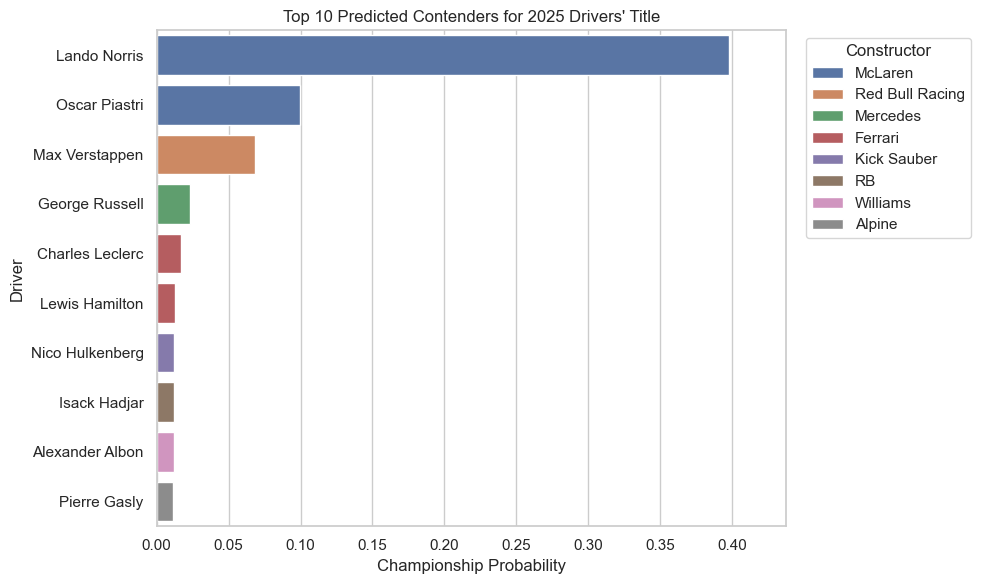

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x='championship_probability',
    y='driver_name',
    hue='constructor_name',
    dodge=False
)
plt.xlabel('Championship Probability')
plt.ylabel('Driver')
plt.title('Top 10 Predicted Contenders for 2025 Drivers\' Title')
plt.xlim(0, max(0.4, float(top10['championship_probability'].max()) * 1.1))
plt.legend(title='Constructor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
**Usage notes**

- Set `USE_PRETRAINED = True` (default) to load the pre-trained ensemble from `models/f1_championship_predictor_2025.joblib`. Set to `False` to retrain.
- The dataset `data/f1_championship_data.csv` must include rows for `year == 2025` (current standings) and prior seasons for context.
- Full predictions are saved to `results/f1_2025_championship_predictions.csv`.
- Ensure the notebook's working directory is `notebooks/` so that `../src` is reachable via `project_root`.
- For deeper analysis (feature importances, evaluation), see `src/ml_model.py` and `src/model_evaluator.py`.

## 6) Current 2025 standings snapshot and points gap

,driver_name,constructor_name,points,wins,podiums,races_started,gap_to_leader,points_per_race
0,Lando Norris,McLaren,357,6,16,21,0,17.0000
1,Oscar Piastri,McLaren,356,7,14,21,1,16.9524
2,Max Verstappen,Red Bull Racing,321,5,11,21,36,15.2857
3,George Russell,Mercedes,258,2,8,21,99,12.2857
4,Charles Leclerc,Ferrari,210,0,7,21,147,10.0000
5,Lewis Hamilton,Ferrari,146,0,0,21,211,6.9524
6,Andrea Kimi Antonelli,Mercedes,97,0,1,21,260,4.6190
7,Alexander Albon,Williams,73,0,0,21,284,3.4762
8,Nico Hulkenberg,Kick Sauber,41,0,1,21,316,1.9524
9,Isack Hadjar,RB,39,0,1,21,318,1.8571


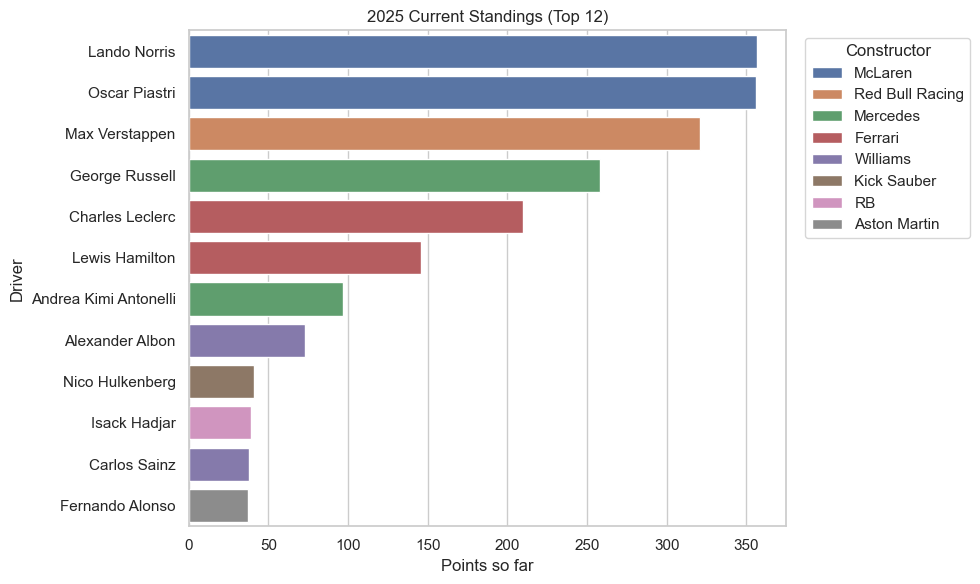

Context: 4 races remaining, ~100 maximum points still available (ignoring sprints/FL).
Top two gap (leader - P2): 1


In [ ]:
standings_2025 = (
    df[df['year'] == 2025]
      .loc[:, ['driver_name','constructor_name','final_points','wins','podiums','races_started']]
      .rename(columns={'final_points':'points'})
      .sort_values('points', ascending=False)
      .reset_index(drop=True)
)

standings_2025['gap_to_leader'] = standings_2025['points'].iloc[0] - standings_2025['points']
standings_2025['points_per_race'] = standings_2025['points'] / standings_2025['races_started'].replace(0, np.nan)

display(standings_2025.head(12))

plt.figure(figsize=(10,6))
sns.barplot(data=standings_2025.head(12), x='points', y='driver_name', hue='constructor_name', dodge=False)
plt.title('2025 Current Standings (Top 12)')
plt.xlabel('Points so far')
plt.ylabel('Driver')
plt.legend(title='Constructor', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

remaining_races = 4
max_points_per_race = 25
print(f"Context: {remaining_races} races remaining, ~{remaining_races*max_points_per_race} maximum points still available (ignoring sprints/FL).")
print('Top two gap (leader - P2):', int(standings_2025['gap_to_leader'].iloc[1]))

## 7) Probability diagnostics (entropy, concentration, top-k sum)

Distribution diagnostics:
  Entropy:        1.948 (higher = more uncertain)
  HHI:            0.291 -> Effective # contenders ≈ 3.43
  Sum of top-1:  0.513
  Sum of top-2:  0.641
  Sum of top-3:  0.729
  Sum of top-5:  0.781


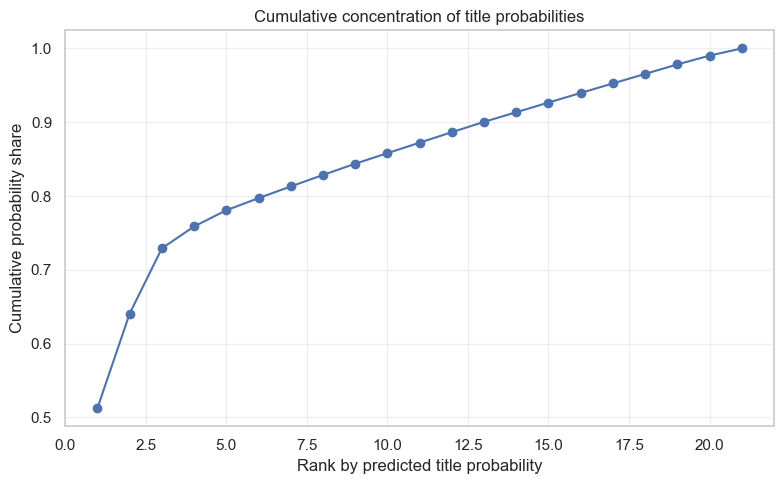

,driver_name,championship_probability,cum_share
13,Lando Norris,0.5126,0.5126
15,Oscar Piastri,0.1281,0.6407
20,Max Verstappen,0.0884,0.7291
16,George Russell,0.0297,0.7588
12,Charles Leclerc,0.0220,0.7808
9,Lewis Hamilton,0.0164,0.7972
10,Nico Hulkenberg,0.0158,0.8130
8,Isack Hadjar,0.0156,0.8285
0,Alexander Albon,0.0152,0.8438
7,Pierre Gasly,0.0143,0.8581


In [ ]:
probs = predictions_2025['championship_probability'].values.astype(float)
probs = probs / probs.sum()

entropy = -np.sum(probs * np.log(probs + 1e-12))
hhi = np.sum(probs**2)
effective_n = 1.0 / hhi if hhi > 0 else np.nan

k_list = [1, 2, 3, 5]
sums_topk = {k: float(np.sort(probs)[::-1][:k].sum()) for k in k_list}

print('Distribution diagnostics:')
print(f"  Entropy:        {entropy:.3f} (higher = more uncertain)")
print(f"  HHI:            {hhi:.3f} -> Effective # contenders ≈ {effective_n:.2f}")
for k, v in sums_topk.items():
    print(f"  Sum of top-{k}:  {v:.3f}")

viz_df = predictions_2025[['driver_name','championship_probability']].copy()
viz_df['championship_probability'] = viz_df['championship_probability'] / viz_df['championship_probability'].sum()
viz_df = viz_df.sort_values('championship_probability', ascending=False)
viz_df['cum_share'] = viz_df['championship_probability'].cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(viz_df)+1), viz_df['cum_share'], marker='o')
plt.xlabel('Rank by predicted title probability')
plt.ylabel('Cumulative probability share')
plt.title('Cumulative concentration of title probabilities')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

viz_df.head(10)

## 8) Monte Carlo of remaining 4 races (points-based skill model)

Monte Carlo champion probabilities (skill from points-per-race):


,driver_name,mc_championship_probability,championship_probability
0,Lando Norris,0.5080,0.3978
1,Oscar Piastri,0.4750,0.0994
2,Max Verstappen,0.0170,0.0686
3,George Russell,0.0000,0.0230
4,Charles Leclerc,0.0000,0.0171
5,Lewis Hamilton,0.0000,0.0127
6,Andrea Kimi Antonelli,0.0000,0.0108
7,Alexander Albon,0.0000,0.0118
8,Nico Hulkenberg,0.0000,0.0123
9,Isack Hadjar,0.0000,0.0121


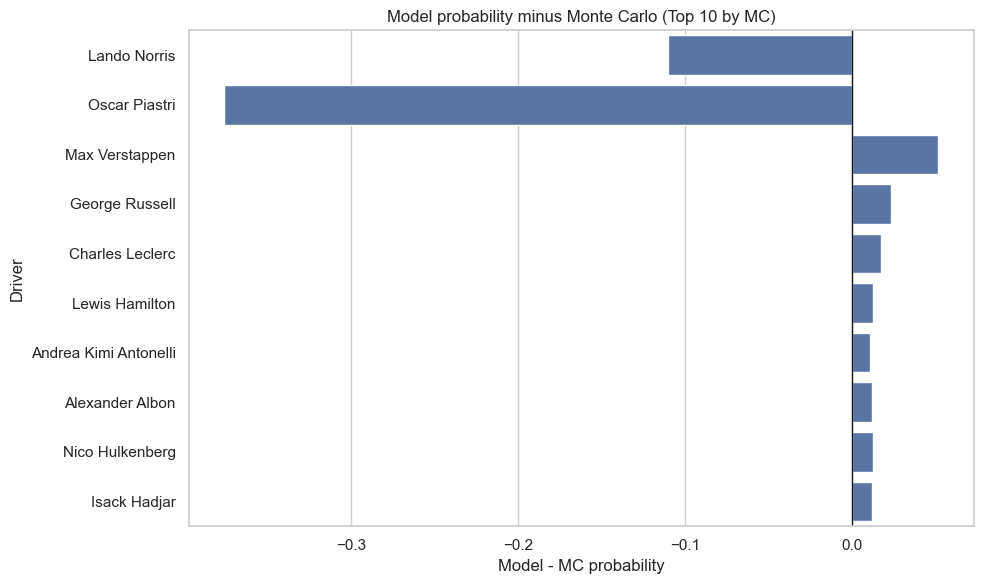

,driver_name,mc_championship_probability,championship_probability
0,Lando Norris,0.5080,0.3978
1,Oscar Piastri,0.4750,0.0994
2,Max Verstappen,0.0170,0.0686
3,George Russell,0.0000,0.0230
4,Charles Leclerc,0.0000,0.0171
5,Lewis Hamilton,0.0000,0.0127
6,Andrea Kimi Antonelli,0.0000,0.0108
7,Alexander Albon,0.0000,0.0118
8,Nico Hulkenberg,0.0000,0.0123
9,Isack Hadjar,0.0000,0.0121


In [ ]:
np.random.seed(42)

race_points = [25,18,15,12,10,8,6,4,2,1]
remaining_races = 4

cur = df[df['year'] == 2025].copy()
cur = cur[['driver_name','constructor_name','final_points','wins','races_started']]
cur = cur.rename(columns={'final_points':'points'})
cur['points_per_race'] = cur['points'] / cur['races_started'].replace(0, np.nan)
cur = cur.sort_values('points', ascending=False).reset_index(drop=True)

beta = 0.40
skill = cur['points_per_race'].fillna(cur['points_per_race'].median()).values
skill = (skill - skill.mean()) / (skill.std() + 1e-9)
weights = np.exp(beta * skill)
weights = weights / weights.sum()

names = cur['driver_name'].tolist()
idx_by_name = {n:i for i,n in enumerate(names)}

S = 5000
champ_counts = np.zeros(len(names), dtype=np.int64)

for s in range(S):
    sim_points = cur['points'].values.astype(float).copy()
    sim_wins = cur['wins'].values.astype(int).copy()

    for r in range(remaining_races):
        available = list(range(len(names)))
        order = []
        w = weights.copy()
        for pos in range(len(names)):
            w_norm = w[available] / w[available].sum()
            choice = np.random.choice(available, p=w_norm)
            order.append(choice)
            available.remove(choice)
        for pos, driver_idx in enumerate(order[:len(race_points)]):
            sim_points[driver_idx] += race_points[pos]
        sim_wins[order[0]] += 1


    top_points = sim_points.max()
    contenders = np.where(sim_points == top_points)[0]
    if len(contenders) > 1:
        # break ties by most wins; if still tied, pick one at random
        wins_subset = sim_wins[contenders]
        max_wins = wins_subset.max()
        contenders = contenders[wins_subset == max_wins]
        if len(contenders) > 1:
            winner = np.random.choice(contenders)
        else:
            winner = contenders[0]
    else:
        winner = contenders[0]

    champ_counts[winner] += 1

mc_probs = champ_counts / S

mc_df = (
    pd.DataFrame({
        'driver_name': names,
        'mc_championship_probability': mc_probs
    })
    .merge(predictions_2025[['driver_name','championship_probability']], on='driver_name', how='left')
    .sort_values('mc_championship_probability', ascending=False)
)

print('Monte Carlo champion probabilities (skill from points-per-race):')
display(mc_df.head(10))

comp = mc_df.copy()
comp['delta_model_minus_mc'] = comp['championship_probability'] - comp['mc_championship_probability']

plt.figure(figsize=(10,6))
sns.barplot(data=comp.head(10), x='delta_model_minus_mc', y='driver_name', orient='h')
plt.axvline(0, color='k', linewidth=1)
plt.title('Model probability minus Monte Carlo (Top 10 by MC)')
plt.xlabel('Model - MC probability')
plt.ylabel('Driver')
plt.tight_layout()
plt.show()

mc_df.head(10)

## 9) Optional: temperature-scaling to reduce overconfidence

Chosen temperature T = 1.006 (aiming to align top-1 with MC)


,driver_name,constructor_name,championship_probability,prob_T,mc_championship_probability
0,Lando Norris,McLaren,0.3978,0.5080,0.5080
1,Oscar Piastri,McLaren,0.0994,0.1283,0.4750
2,Max Verstappen,Red Bull Racing,0.0686,0.0887,0.0170
3,George Russell,Mercedes,0.0230,0.0300,0.0000
4,Charles Leclerc,Ferrari,0.0171,0.0223,0.0000
5,Lewis Hamilton,Ferrari,0.0127,0.0166,0.0000
6,Nico Hulkenberg,Kick Sauber,0.0123,0.0161,0.0000
7,Isack Hadjar,RB,0.0121,0.0158,0.0000
8,Alexander Albon,Williams,0.0118,0.0155,0.0000
9,Pierre Gasly,Alpine,0.0111,0.0145,0.0000


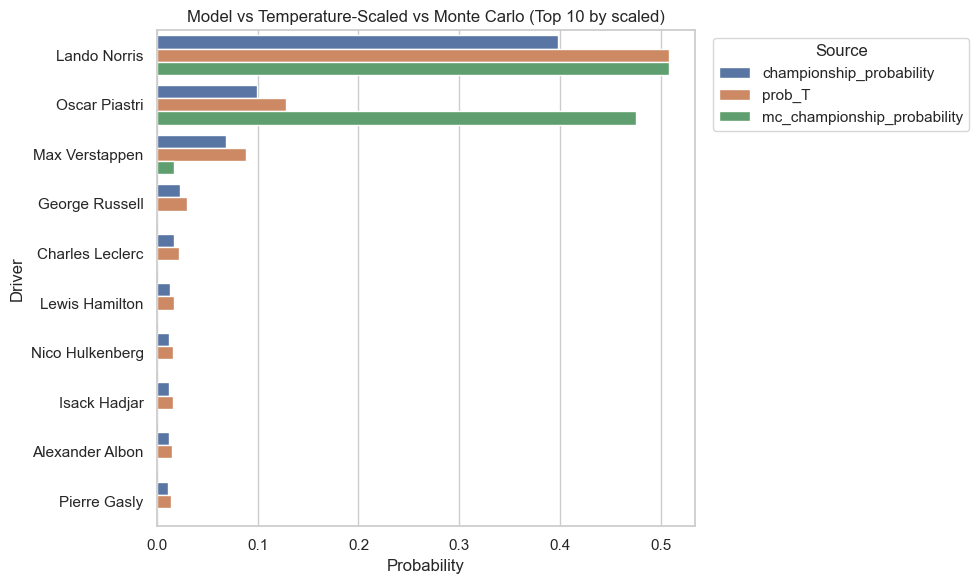

Saved calibrated probabilities to: g:\My Drive\Coding\Git Clones\MLF1\results\f1_2025_championship_predictions_calibrated.csv


In [ ]:
from scipy.special import expit, logit

def temp_scale_probs(df_probs, T=1.0):
    p = df_probs['championship_probability'].values.astype(float)
    eps = 1e-9
    logits = np.log(np.clip(p, eps, 1-eps)) - np.log(1 - np.clip(p, eps, 1-eps))
    logits_T = logits / T
    p_T = expit(logits_T)
    p_T = p_T / p_T.sum()
    out = df_probs.copy()
    out['prob_T'] = p_T
    return out

if 'mc_df' in locals() and not mc_df.empty:
    target_top = float(mc_df['mc_championship_probability'].max())
    base_top = float(predictions_2025['championship_probability'].max())

    def top_after_T(T):
        tmp = temp_scale_probs(predictions_2025, T)
        return float(tmp['prob_T'].max())

    low, high = 0.5, 5.0
    for _ in range(30):
        mid = 0.5 * (low + high)
        if top_after_T(mid) > target_top:
            low = mid
        else:
            high = mid
    T_star = high
else:
    T_star = 1.5

scaled = temp_scale_probs(predictions_2025, T=T_star)

calib = predictions_2025[['driver_name','constructor_name','championship_probability']].copy()
calib = calib.merge(scaled[['driver_name','prob_T']], on='driver_name')
calib = calib.merge(mc_df[['driver_name','mc_championship_probability']], on='driver_name', how='left')
calib = calib.sort_values('prob_T', ascending=False)

print(f"Chosen temperature T = {T_star:.3f} (aiming to align top-1 with MC)")
display(calib.head(10))

plt.figure(figsize=(10,6))
plot_df = calib.head(10).melt(id_vars=['driver_name'], value_vars=['championship_probability','prob_T','mc_championship_probability'],
                              var_name='source', value_name='probability')
sns.barplot(data=plot_df, x='probability', y='driver_name', hue='source')
plt.title('Model vs Temperature-Scaled vs Monte Carlo (Top 10 by scaled)')
plt.xlabel('Probability')
plt.ylabel('Driver')
plt.legend(title='Source', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

recalib_path = os.path.join(results_dir, 'f1_2025_championship_predictions_calibrated.csv')
calib[['driver_name','constructor_name','prob_T']].rename(columns={'prob_T':'calibrated_probability'}).to_csv(recalib_path, index=False)
print('Saved calibrated probabilities to:', recalib_path)

## 10) Head-to-head scenario explorer (final 4 races)

Head-to-head drivers: Lando Norris vs Oscar Piastri


,scenario,final_Lando Norris,final_Oscar Piastri,Lando Norris - Oscar Piastri,wins_Lando Norris,wins_Oscar Piastri
8,B DNF once (A P2),420,401,19,0,0
3,A win + B P2 each race,436,428,8,1,0
5,One swing race (A wins once),427,419,8,1,0
0,Neutral P3 all races,417,416,1,0,0
1,"Split wins 2-2 (A wins R1,R3)",443,442,1,2,2
2,"Split wins 2-2 (B wins R1,R3)",443,442,1,2,2
9,All P2 finishes,429,428,1,0,0
4,B win + A P2 each race,429,435,-6,0,1
6,One swing race (B wins once),420,426,-6,0,1
7,A DNF once (B P2),402,419,-17,0,0


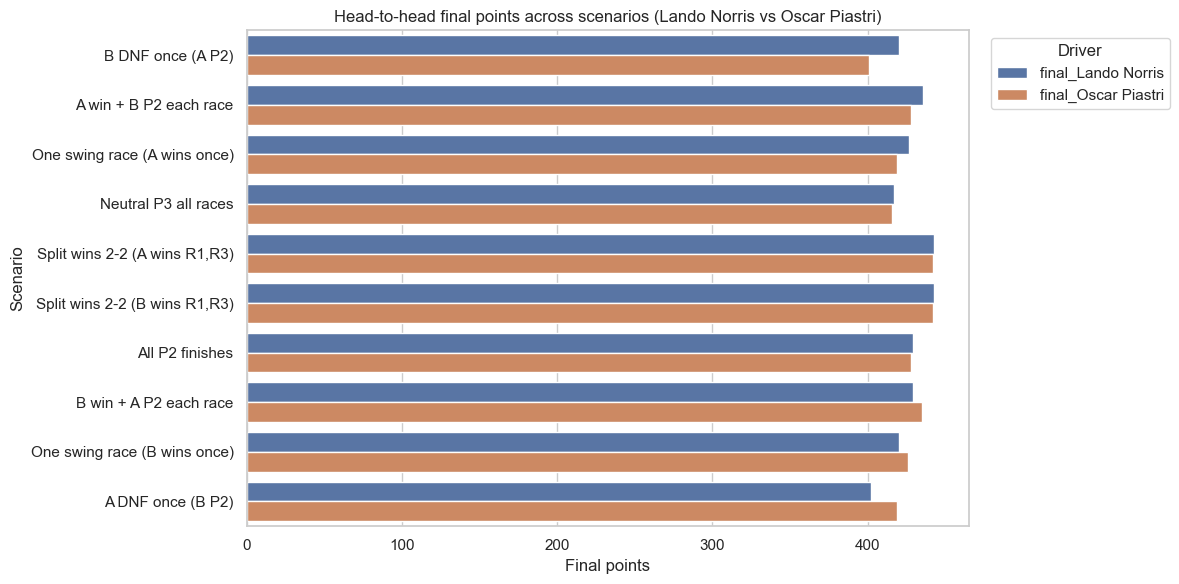

,race,A_pos,B_pos,A_minus_B
0,1,1,1,1
1,1,1,2,8
2,1,1,3,11
3,1,1,4,14
4,1,1,5,16


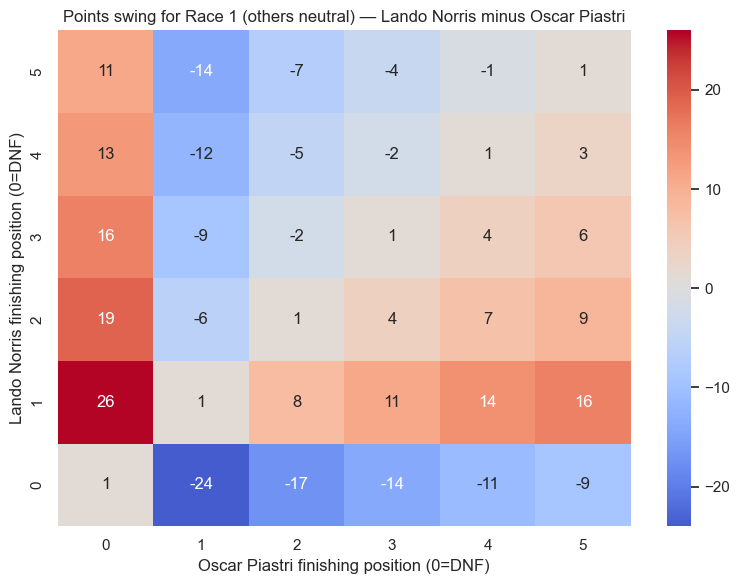

In [ ]:
cur = df[df['year'] == 2025].copy()
cur = cur[['driver_name','final_points']].rename(columns={'final_points':'points'})
cur = cur.sort_values('points', ascending=False).reset_index(drop=True)

driver_A = cur.loc[0, 'driver_name']
driver_B = cur.loc[1, 'driver_name']

print('Head-to-head drivers:', driver_A, 'vs', driver_B)

POINTS = {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}

def pts(pos):
    if pos is None or pos == 0:
        return 0
    return POINTS.get(int(pos), 0)

def simulate_h2h(scenario, dA=driver_A, dB=driver_B):
    base_points = dict(cur.set_index('driver_name')['points'])
    pA = base_points[dA]
    pB = base_points[dB]
    winsA = 0
    winsB = 0
    for (pa, pb) in scenario:
        pA += pts(pa)
        pB += pts(pb)
        if pa == 1: winsA += 1
        if pb == 1: winsB += 1
    return {
        'driver_A': dA, 'driver_B': dB,
        'final_A': pA, 'final_B': pB,
        'diff_A_minus_B': pA - pB,
        'wins_A': winsA, 'wins_B': winsB,
        'scenario': scenario
    }

presets = {
    'Neutral P3 all races':               [(3,3),(3,3),(3,3),(3,3)],
    'Split wins 2-2 (A wins R1,R3)':      [(1,2),(2,1),(1,2),(2,1)],
    'Split wins 2-2 (B wins R1,R3)':      [(2,1),(1,2),(2,1),(1,2)],
    'A win + B P2 each race':             [(1,2),(2,2),(2,2),(2,2)],
    'B win + A P2 each race':             [(2,1),(2,2),(2,2),(2,2)],
    'One swing race (A wins once)':       [(1,2),(3,3),(3,3),(3,3)],
    'One swing race (B wins once)':       [(2,1),(3,3),(3,3),(3,3)],
    'A DNF once (B P2)':                  [(0,2),(3,3),(3,3),(3,3)],
    'B DNF once (A P2)':                  [(2,0),(3,3),(3,3),(3,3)],
    'All P2 finishes':                    [(2,2),(2,2),(2,2),(2,2)]
}

rows = []
for name, scen in presets.items():
    res = simulate_h2h(scen)
    rows.append({
        'scenario': name,
        'final_'+driver_A: res['final_A'],
        'final_'+driver_B: res['final_B'],
        driver_A+' - '+driver_B: res['diff_A_minus_B'],
        'wins_'+driver_A: res['wins_A'],
        'wins_'+driver_B: res['wins_B']
    })

h2h_df = pd.DataFrame(rows).sort_values(driver_A+' - '+driver_B, ascending=False)
display(h2h_df)

plot_df = h2h_df.melt(id_vars=['scenario'], value_vars=['final_'+driver_A, 'final_'+driver_B],
                      var_name='driver', value_name='final_points')
plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x='final_points', y='scenario', hue='driver')
plt.title(f'Head-to-head final points across scenarios ({driver_A} vs {driver_B})')
plt.xlabel('Final points')
plt.ylabel('Scenario')
plt.legend(title='Driver', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

neutral = [(3,3),(3,3),(3,3),(3,3)]

def swing_table(pos_list=[1,2,3,4,5,6,7,8,9,10,0]):
    rows = []
    for r in range(4):
        for a_pos in pos_list:
            for b_pos in pos_list:
                scen = list(neutral)
                scen[r] = (a_pos, b_pos)
                res = simulate_h2h(scen)
                rows.append({'race': r+1, 'A_pos': a_pos, 'B_pos': b_pos, 'A_minus_B': res['diff_A_minus_B']})
    return pd.DataFrame(rows)

swing_df = swing_table(pos_list=[1,2,3,4,5,0])
display(swing_df.head())

heat = swing_df[swing_df['race']==1].pivot(index='A_pos', columns='B_pos', values='A_minus_B').sort_index(ascending=False)
plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True, fmt='.0f', cmap='coolwarm', center=0)
plt.title(f'Points swing for Race 1 (others neutral) — {driver_A} minus {driver_B}')
plt.xlabel(f'{driver_B} finishing position (0=DNF)')
plt.ylabel(f'{driver_A} finishing position (0=DNF)')
plt.tight_layout()
plt.show()

## Portfolio showcase & season finale

This notebook delivers a complete, reproducible machine learning system for predicting the 2025 Formula 1 Drivers' Championship using current-season standings combined with historical context. It exemplifies end-to-end applied data science: feature engineering, ensemble modelling, calibration, simulation-based scenario analysis, and clear data visualisation.

### Technical highlights

- **Feature engineering**: domain-informed metrics engineered from season and historical data to capture driver and constructor performance.
- **Ensemble modelling**: multiple algorithms combined with probability calibration for robust, interpretable predictions.
- **Diagnostic analysis**: uncertainty metrics (entropy, HHI), Monte Carlo race simulations, and head-to-head scenario exploration with swing heatmaps.
- **Reproducible outputs**: structured CSVs (`../results/f1_2025_championship_predictions.csv` and calibrated variants), automated figure generation (`../assets/*.png`), and modular Python codebase.

### Key skills demonstrated

- Feature engineering and domain-informed modelling (driver and constructor-level features).
- Ensemble modelling, calibration, and probability interpretation.
- Simulation-based scenario analysis (Monte Carlo) and deterministic head-to-head exploration.
- Clear, reproducible analysis with well-documented outputs and automated visualisation for presentations.
- Data storytelling to communicate model insights to both technical and non-technical audiences.

### How to reproduce

1. Install dependencies from the repository root:
```bash
pip install -r requirements.txt
```
2. Run the notebook (ensure the working directory is `notebooks/` so `..` is the project root). Set `USE_PRETRAINED = True` to use the pre-trained model.
3. Regenerate README visuals (optional):
```bash
python scripts/generate_readme_images.py
```
4. Output files:
   - Predictions: `results/f1_2025_championship_predictions.csv`
   - Calibrated probabilities (if run): `results/f1_2025_championship_predictions_calibrated.csv`
   - Assets: `assets/*.png`

### Recommended next steps

- Run the Monte Carlo and head-to-head scenario cells after each race to update probabilities and visual summaries.
- Experiment with calibration targets or ensemble weights for different probability spreads.
- Package the notebook into a short public-facing report or interactive dashboard for your portfolio site.

### Final note — the season finale awaits

The 2025 title race is alive. This project combines rigorous modelling with clear storytelling so you can show not just who is likely to win, but why — and which races or incidents will swing the outcome. Use the visualisations to fuel discussions, social posts, or a short explainer video for your portfolio. For a polished one-page PDF report summarising current probabilities and top scenarios (ideal for LinkedIn or portfolio sharing), simply ask.